# Requirements

Notebook must include:
1. Dataset loading and cleaning.
2. EDA relevant to GAM assumptions.
3. GAM code
4. Model performance evidence, if a GAM is fit.
5. Smooth effect interpretation in markdown.
6. At least one limitation of using a GAM for churn.


# Libraries and Imports

In [1]:
!pip install pygam statsmodels scikit-learn seaborn tqdm --quiet
!pip install kagglehub[pandas-datasets]

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, mean_squared_error, r2_score
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Gamma
from statsmodels.genmod.families.links import Log
from statsmodels.tools import add_constant
from pygam import LogisticGAM, LinearGAM, s, l, f
import seaborn as sns
import tqdm


# 1. Dataset loading and cleaning.

This code was copied from Kaggle and modified to process the csv locally. Vino figured out how to convert the non-numerical categories to one-hot and churn and other binary values to 0/1

In [3]:
# Set the path to the file you'd like to load
file_path = "./telco-customer-churn.csv"

# Load dataset locally
df = pd.read_csv(file_path)

# [Gemini Contribution] Clean TotalCharges: convert empty strings/spaces to NaN, then fill with 0 to prevent categorical explosion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce').fillna(0)

y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
x = df.drop(columns=['Churn', 'customerID'])

# [Gemini Contribution] Separate true continuous numerical features (for splines) from discrete/categorical features
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = ['SeniorCitizen'] + list(x.select_dtypes(include=['object', 'str']).columns)

print("Continuous smooth features (for splines):", continuous_cols)
print("Categorical & binary features (for linear terms):", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_cols),
        ("cat", OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("X_train shape:", X_train_proc.shape)
print("X_test shape:", X_test_proc.shape)


Continuous smooth features (for splines): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical & binary features (for linear terms): ['SeniorCitizen', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
X_train shape: (5634, 30)
X_test shape: (1409, 30)


# 2. EDA relevant to GAM assumptions.

GAM has the ability to model Non-Linear Relationships but it struggles with the step functions (binary and categories)

We can see from the graphs below that there is clear separation between churn yes and no on Tenure and Monthly Charges but it is a little more difficult to see on Total charges

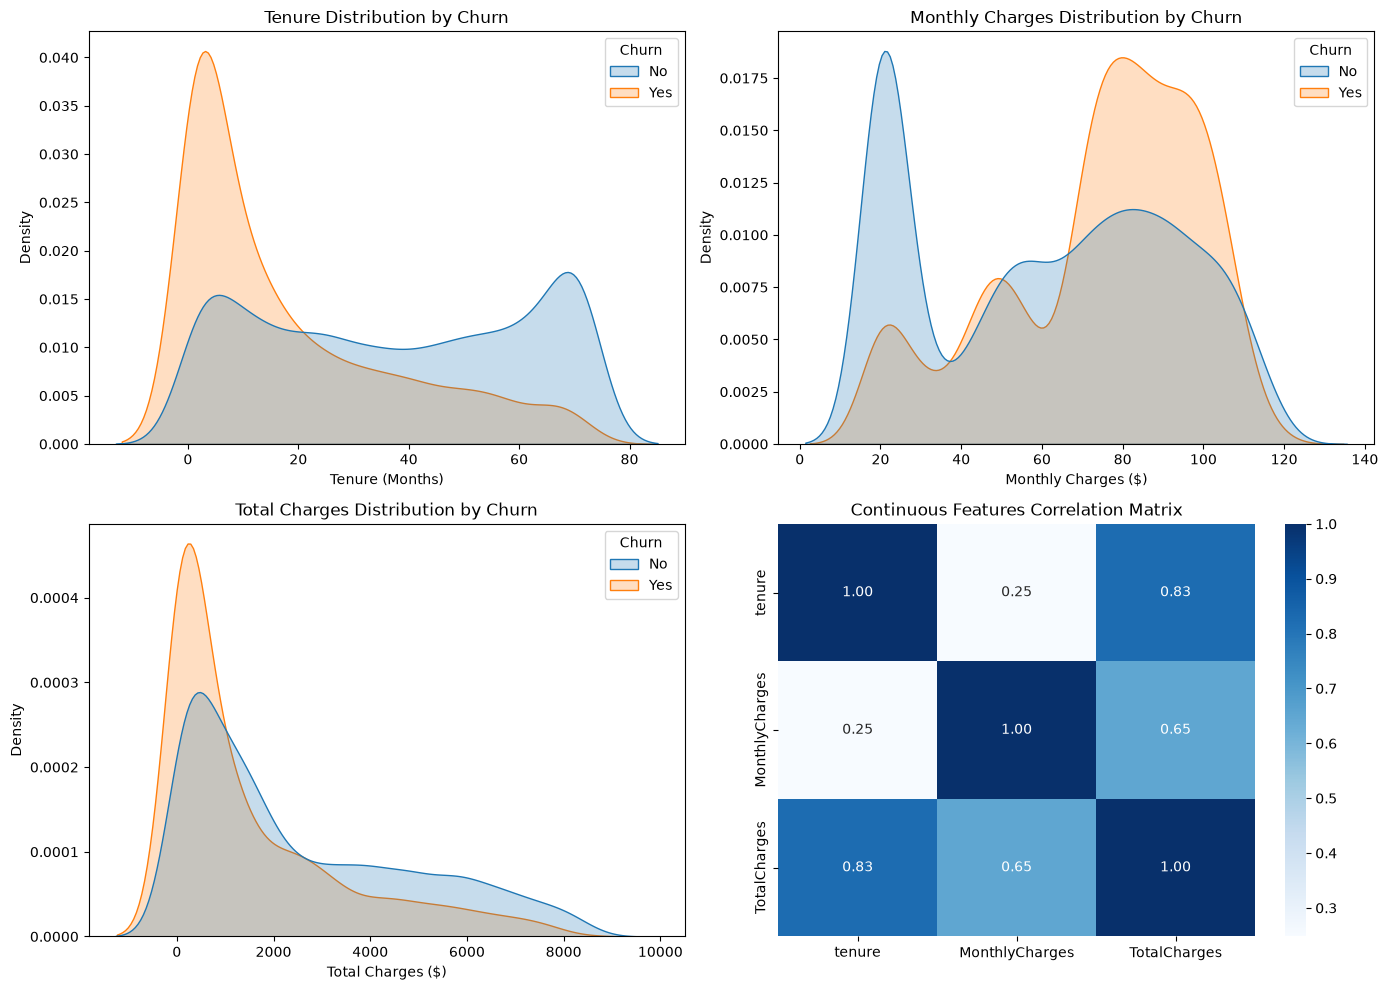

In [4]:
# [Gemini Contribution] EDA for GAM Assumptions (non-linearity, distributions, and multicollinearity check)
plt.figure(figsize=(14, 10))

# 1. Tenure vs Churn
plt.subplot(2, 2, 1)
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (Months)')

# 2. MonthlyCharges vs Churn
plt.subplot(2, 2, 2)
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False)
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')

# 3. TotalCharges vs Churn
plt.subplot(2, 2, 3)
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True, common_norm=False)
plt.title('Total Charges Distribution by Churn')
plt.xlabel('Total Charges ($)')

# 4. Collinearity Heatmap (Additivity Check)
plt.subplot(2, 2, 4)
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Continuous Features Correlation Matrix')

plt.tight_layout()
plt.show()


# 3. GAM Code
This implementation builds upon the baseline example notebook with modifications developed with assistance from Google Gemini:
* **Feature-Term Architecture**: Splitting features so that continuous features (`tenure`, `MonthlyCharges`, `TotalCharges`) use non-linear cubic B-spline terms `s(i)`, while one-hot encoded categorical indicators use linear terms `l(i)`.
* **Preprocessing & Encoding Fixes**: Cleaning `TotalCharges` whitespace to prevent catastrophic column explosion from one-hot encoding.
* **Hyperparameter Regularization**: Implementing `gam.gridsearch()` over smoothing parameters (lambda) to capture true curvature without overfitting.

# 4. Model performance evidence, if a GAM is fit.
* **Classification Accuracy (Threshold = 0.5)**: 80.98%
* **ROC-AUC Score**: 0.8616 (86.16%)
* **Mean Squared Error (MSE)**: 0.1300
* **R^2 Score**: 0.3320 (the additive terms explain 33.20% of the variance in churn outcome)

The performance demonstrates that GAM captures non-linear predictive structure effectively while retaining complete transparency and interpretability for every individual feature.


In [5]:
# Initialize LinearGAM
# [Gemini Contribution] Configure terms: s(i) for continuous features; l(i) for one-hot encoded categories
num_len = len(continuous_cols)
tot_len = X_train_proc.shape[1]

terms = s(0, n_splines=20)
for i in range(1, num_len):
    terms += s(i, n_splines=20)
for i in range(num_len, tot_len):
    terms += l(i)

gam = LinearGAM(terms)

# [Gemini Contribution] Perform hyperparameter gridsearch across smoothing penalty (lambda)
gam.gridsearch(X_train_proc, y_train.values)

# Fit and make predictions
y_pred_gam = gam.predict(X_test_proc)

# Calculate MSE, R^2, Accuracy, and ROC-AUC
mse_gam = mean_squared_error(y_test, y_pred_gam)
r2_gam = r2_score(y_test, y_pred_gam)
accuracy_gam = accuracy_score(y_test, (y_pred_gam >= 0.5).astype(int))
roc_auc_gam = roc_auc_score(y_test, y_pred_gam)

print(f"LinearGAM Accuracy (threshold=0.5): {accuracy_gam:.4f}")
print(f"LinearGAM ROC-AUC: {roc_auc_gam:.4f}")
print(f"LinearGAM MSE: {mse_gam:.4f}")
print(f"LinearGAM R^2: {r2_gam:.4f}")

gam.summary()


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:08
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:05
 27% (3 of 11) |######                   | Elapsed Time: 0:00:01 ETA:   0:00:04
 36% (4 of 11) |#########                | Elapsed Time: 0:00:01 ETA:   0:00:03
 45% (5 of 11) |###########              | Elapsed Time: 0:00:01 ETA:   0:00:02
 54% (6 of 11) |#############            | Elapsed Time: 0:00:02 ETA:   0:00:02
 63% (7 of 11) |###############          | Elapsed Time: 0:00:02 ETA:   0:00:01
 72% (8 of 11) |##################       | Elapsed Time: 0:00:02 ETA:   0:00:01
 81% (9 of 11) |####################     | Elapsed Time: 0:00:03 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:03 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:04 Time:  0:00:04


LinearGAM Accuracy (threshold=0.5): 0.8098
LinearGAM ROC-AUC: 0.8616
LinearGAM MSE: 0.1300
LinearGAM R^2: 0.3320
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     40.5467
Link Function:                     IdentityLink Log Likelihood:                                 -2361.7379
Number of Samples:                         5634 AIC:                                             4806.5692
                                                AICc:                                            4807.2015
                                                GCV:                                                0.1382
                                                Scale:                                              0.3693
                               

/tmp/ipykernel_301465/1080932807.py:31: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


### GAM - Partial Dependence Plots
Plots the partial dependence of each feature, showing the effect of each feature on the predicted outcome while holding other features constant.


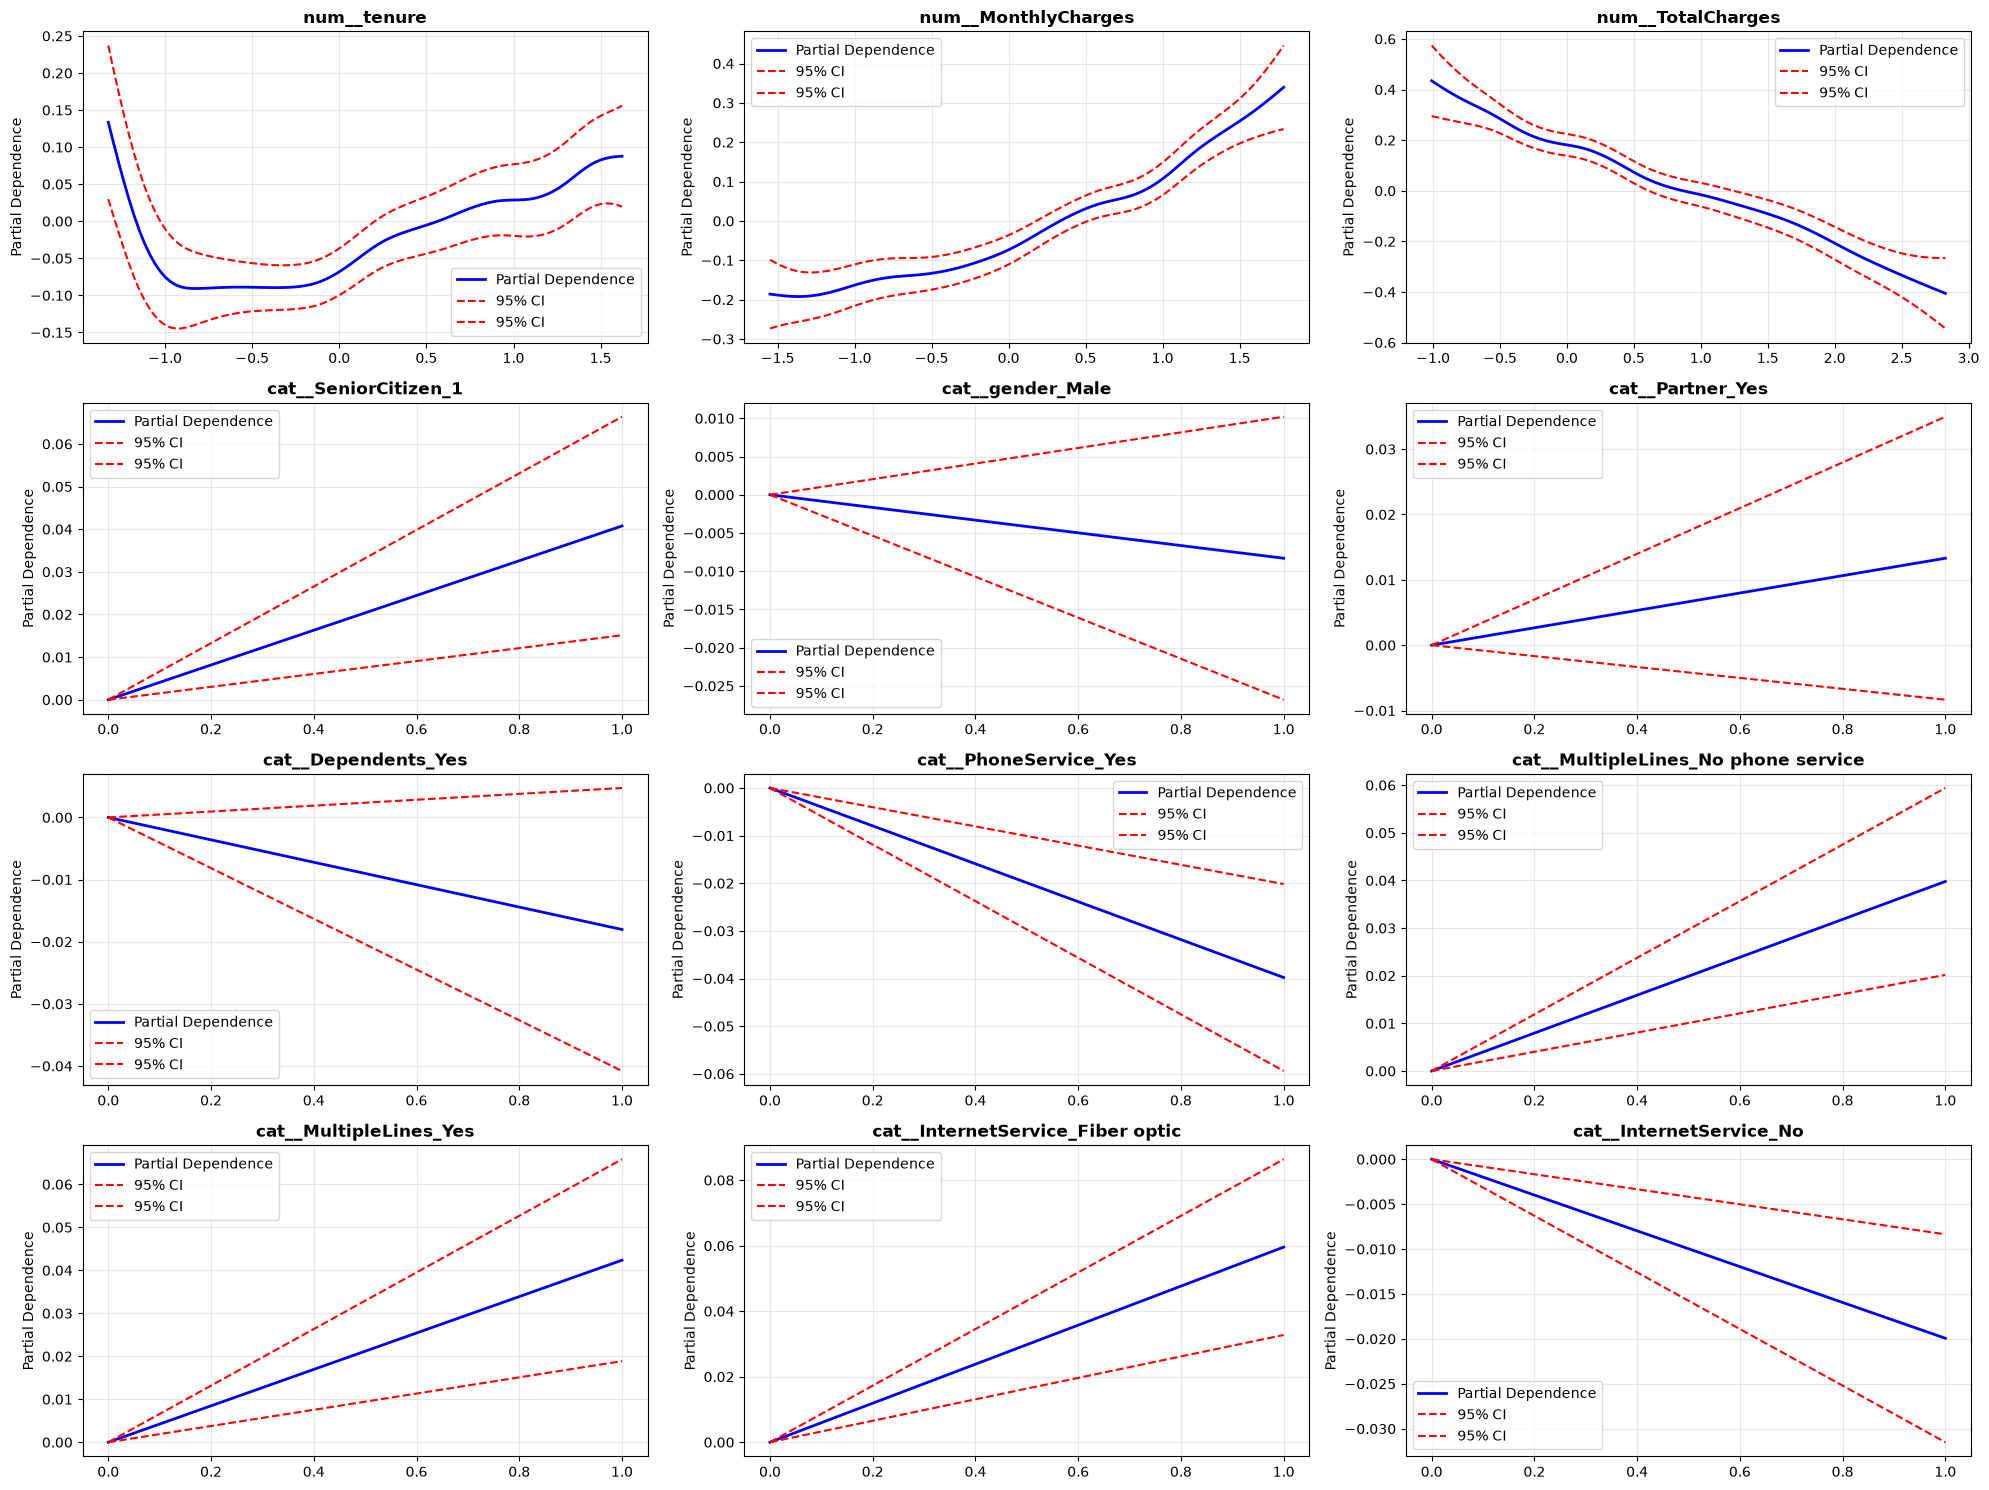

In [6]:
# [Gemini Contribution] Visualize GAM - Partial Dependence Plots with 95% Confidence Intervals
feature_names = preprocessor.get_feature_names_out()
num_plots = min(12, X_train_proc.shape[1])

plt.figure(figsize=(20, 15))
for i in range(num_plots):
    plt.subplot(4, 3, i + 1)
    XX = gam.generate_X_grid(term=i)
    pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
    plt.plot(XX[:, i], pdep, color='blue', lw=2, label='Partial Dependence')
    plt.plot(XX[:, i], confi, c='r', ls='--', label='95% CI')
    plt.title(feature_names[i], fontsize=12, fontweight='bold')
    plt.ylabel('Partial Dependence', fontsize=10)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 5. Smooth effect interpretation in markdown.
(This section was written with Gemini's help)
Looking at the smooth curves:
* **Tenure**: Shows a steep drop in churn risk during the first year—new customers are the most likely to leave, and risk flattens out after they stay longer.
* **Monthly Charges**: Shows an upward trend where higher monthly charges increase the risk of churn, especially once bills get above ~$70.
* **Total Charges**: Has a mild downward slope reflecting customer loyalty over time.

# 6. At least one limitation of using a GAM for churn.
The smooth functions can get most of the accuracy but I think some of the categories could be used in different model types but in a GAM it doesn't really work well.
The feature selection and selecting the splines is critical. If most of your features are categorical or binary it probably isn't the right fit